# Data Exploration

Analyzes the CompCars dataset structure and statistics.

This notebook:
- Analyzes train/test split files
- Computes class distribution statistics
- Generates distribution plots
- Tests dataset loading functionality

## 1. Setup

In [1]:
# imports
import os
import sys
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

# add src to path
sys.path.insert(0, str(Path('.').absolute()))

from src.dataset import (
    CompCarsDataset,
    get_train_transforms,
    get_val_transforms
)

## 2. Configuration

In [2]:
# paths
DATA_DIR = Path("dataset/data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

TRAIN_SPLIT = DATA_DIR / "train_test_split/classification/train.txt"
TEST_SPLIT = DATA_DIR / "train_test_split/classification/test.txt"

print(f"train split: {TRAIN_SPLIT}")
print(f"test split: {TEST_SPLIT}")

train split: dataset\data\train_test_split\classification\train.txt
test split: dataset\data\train_test_split\classification\test.txt


## 3. Analysis Functions

In [3]:
def analyze_split_file(split_file: str) -> dict:
    # analyze a train/test split file

    with open(split_file, 'r') as f:
        lines = f.readlines()

    # parse all entries
    makes = []
    models = []
    years = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        parts = line.split('/')
        make_id = int(parts[0])
        model_id = int(parts[1])
        year_str = parts[2]

        makes.append(make_id)
        models.append((make_id, model_id))

        # handle unknown years - use 0 as placeholder to filter later
        if year_str == 'unknown':
            year = 0
        else:
            year = int(year_str)
        years.append(year)

    # compute statistics
    make_counts = Counter(makes)
    model_counts = Counter(models)
    year_counts = Counter(years)

    stats = {}
    stats['total_images'] = len(lines)
    stats['unique_makes'] = len(make_counts)
    stats['unique_models'] = len(model_counts)
    stats['unique_years'] = len(year_counts)
    stats['make_counts'] = make_counts
    stats['model_counts'] = model_counts
    stats['year_counts'] = year_counts

    # compute samples per class stats
    make_samples = list(make_counts.values())
    stats['make_min_samples'] = min(make_samples)
    stats['make_max_samples'] = max(make_samples)
    stats['make_mean_samples'] = np.mean(make_samples)
    stats['make_std_samples'] = np.std(make_samples)

    model_samples = list(model_counts.values())
    stats['model_min_samples'] = min(model_samples)
    stats['model_max_samples'] = max(model_samples)
    stats['model_mean_samples'] = np.mean(model_samples)
    stats['model_std_samples'] = np.std(model_samples)

    return stats

## 4. Plotting Functions

In [4]:
def get_count_value(item):
    # extract count value from (class_id, count) tuple for sorting
    count = item[1]
    return count


def plot_class_distribution(
    counts: Counter,
    title: str,
    output_path: str,
    top_n: int = 30
) -> None:
    # plot class distribution histogram

    values = list(counts.values())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # histogram of samples per class
    axes[0].hist(values, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('samples per class')
    axes[0].set_ylabel('number of classes')
    axes[0].set_title(f'{title} - distribution')
    axes[0].axvline(
        np.mean(values),
        color='red',
        linestyle='--',
        label=f'mean: {np.mean(values):.1f}'
    )
    axes[0].legend()

    # top n classes bar chart
    sorted_counts = sorted(counts.items(), key=get_count_value, reverse=True)
    top_classes = sorted_counts[:top_n]

    class_labels = []
    class_values = []
    for class_id, count in top_classes:
        if isinstance(class_id, tuple):
            label = f"{class_id[0]}/{class_id[1]}"
        else:
            label = str(class_id)
        class_labels.append(label)
        class_values.append(count)

    axes[1].barh(range(len(class_values)), class_values, color='steelblue')
    axes[1].set_yticks(range(len(class_labels)))
    axes[1].set_yticklabels(class_labels, fontsize=8)
    axes[1].set_xlabel('number of samples')
    axes[1].set_title(f'{title} - top {top_n} classes')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    print(f"saved: {output_path}")

In [5]:
def plot_year_distribution(year_counts: Counter, output_path: str) -> None:
    # plot year distribution, ignoring unknown years

    # filter out unknown years (stored as 0)
    filtered_counts = {}
    for year, count in year_counts.items():
        if year != 0:
            filtered_counts[year] = count

    sorted_years = sorted(filtered_counts.items())

    years = []
    counts = []
    for year, count in sorted_years:
        years.append(year)
        counts.append(count)

    min_year = min(years)
    max_year = max(years)

    plt.figure(figsize=(12, 5))
    plt.bar(years, counts, color='steelblue', edgecolor='black')
    plt.xlabel('year')
    plt.ylabel('number of images')
    plt.title(f'images per year ({min_year}-{max_year})')
    plt.xlim(min_year - 0.5, max_year + 0.5)
    plt.xticks(range(min_year, max_year + 1), rotation=45)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    print(f"saved: {output_path}")

## 5. Report Generation

In [ ]:
def save_statistics_report(
    train_stats: dict,
    test_stats: dict,
    output_path: str
) -> None:
    # save statistics to markdown file -> results/compcars_statistics.md
    # used for the report later, gonna import it into my obsidian vault
    with open(output_path, 'w') as f:
        f.write("# CompCars Dataset Statistics\n\n")
        f.write(f"generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        f.write("## Source\n\n")
        f.write("**URL:** http://mmlab.ie.cuhk.edu.hk/datasets/comp_cars/index.html\n\n")
        f.write("**Citation:**\n")
        f.write("> Linjie Yang, Ping Luo, Chen Change Loy, Xiaoou Tang. ")
        f.write("\"A Large-Scale Car Dataset for Fine-Grained Categorization and Verification\", ")
        f.write("In Computer Vision and Pattern Recognition (CVPR), 2015.\n\n")

        f.write("## Overview\n\n")
        f.write("| Split | Images | Makes | Models | Years |\n")
        f.write("|-------|--------|-------|--------|-------|\n")
        f.write(f"| Train | {train_stats['total_images']} | ")
        f.write(f"{train_stats['unique_makes']} | ")
        f.write(f"{train_stats['unique_models']} | ")
        f.write(f"{train_stats['unique_years']} |\n")
        f.write(f"| Test | {test_stats['total_images']} | ")
        f.write(f"{test_stats['unique_makes']} | ")
        f.write(f"{test_stats['unique_models']} | ")
        f.write(f"{test_stats['unique_years']} |\n")
        f.write(f"| Total | {train_stats['total_images'] + test_stats['total_images']} | ")
        f.write(f"- | - | - |\n\n")

        f.write("## Make Classification (Coarse-grained)\n\n")
        f.write("| Metric | Train | Test |\n")
        f.write("|--------|-------|------|\n")
        f.write(f"| Number of classes | {train_stats['unique_makes']} | ")
        f.write(f"{test_stats['unique_makes']} |\n")
        f.write(f"| Min samples/class | {train_stats['make_min_samples']} | ")
        f.write(f"{test_stats['make_min_samples']} |\n")
        f.write(f"| Max samples/class | {train_stats['make_max_samples']} | ")
        f.write(f"{test_stats['make_max_samples']} |\n")
        f.write(f"| Mean samples/class | {train_stats['make_mean_samples']:.1f} | ")
        f.write(f"{test_stats['make_mean_samples']:.1f} |\n")
        f.write(f"| Std samples/class | {train_stats['make_std_samples']:.1f} | ")
        f.write(f"{test_stats['make_std_samples']:.1f} |\n\n")

        f.write("## Model Classification (Fine-grained)\n\n")
        f.write("| Metric | Train | Test |\n")
        f.write("|--------|-------|------|\n")
        f.write(f"| Number of classes | {train_stats['unique_models']} | ")
        f.write(f"{test_stats['unique_models']} |\n")
        f.write(f"| Min samples/class | {train_stats['model_min_samples']} | ")
        f.write(f"{test_stats['model_min_samples']} |\n")
        f.write(f"| Max samples/class | {train_stats['model_max_samples']} | ")
        f.write(f"{test_stats['model_max_samples']} |\n")
        f.write(f"| Mean samples/class | {train_stats['model_mean_samples']:.1f} | ")
        f.write(f"{test_stats['model_mean_samples']:.1f} |\n")
        f.write(f"| Std samples/class | {train_stats['model_std_samples']:.1f} | ")
        f.write(f"{test_stats['model_std_samples']:.1f} |\n\n")

        f.write("## Class Imbalance Analysis\n\n")
        train_imbalance = train_stats['make_max_samples'] / train_stats['make_min_samples']
        f.write(f"- make imbalance ratio (max/min): {train_imbalance:.1f}x\n")
        model_imbalance = train_stats['model_max_samples'] / train_stats['model_min_samples']
        f.write(f"- model imbalance ratio (max/min): {model_imbalance:.1f}x\n")
        f.write("\n")

        f.write("## Figures\n\n")
        f.write("- `make_distribution.png` - samples per make class\n")
        f.write("- `model_distribution.png` - samples per model class\n")
        f.write("- `year_distribution.png` - images per year\n")

    print(f"saved: {output_path}")

## 6. Dataset Loading Test

In [ ]:
def test_dataset_loading(root_dir: str, split_file: str) -> bool:
    # test that dataset loading works correctly

    print("testing dataset loading...")
    transform = get_val_transforms()
    # test make task
    dataset = CompCarsDataset(
        root_dir=root_dir,
        split_file=split_file,
        transform=transform,
        task='make'
    )

    print(f"  dataset size: {len(dataset)}")
    print(f"  num makes: {dataset.num_makes}")
    print(f"  num models: {dataset.num_models}")

    # load first sample
    image, label = dataset[0]
    print(f"  sample image shape: {image.shape}")
    print(f"  sample label: {label}")

    # verify image dimensions
    is_valid = True

    if image.shape[0] != 3:
        print("  error: expected 3 channels")
        is_valid = False

    if image.shape[1] != 224:
        print("  error: expected height 224")
        is_valid = False

    if image.shape[2] != 224:
        print("  error: expected width 224")
        is_valid = False

    if is_valid:
        print("  dataset loading test passed!")

    return is_valid

## 7. Analyze Dataset Splits

In [8]:
# analyze train split
print("analyzing train split...")
train_stats = analyze_split_file(str(TRAIN_SPLIT))
print(f"  images: {train_stats['total_images']}")
print(f"  makes: {train_stats['unique_makes']}")
print(f"  models: {train_stats['unique_models']}")

analyzing train split...
  images: 16016
  makes: 75
  models: 431


In [9]:
# analyze test split
print("analyzing test split...")
test_stats = analyze_split_file(str(TEST_SPLIT))
print(f"  images: {test_stats['total_images']}")
print(f"  makes: {test_stats['unique_makes']}")
print(f"  models: {test_stats['unique_models']}")

analyzing test split...
  images: 14939
  makes: 75
  models: 431


## 8. Generate Distribution Plots

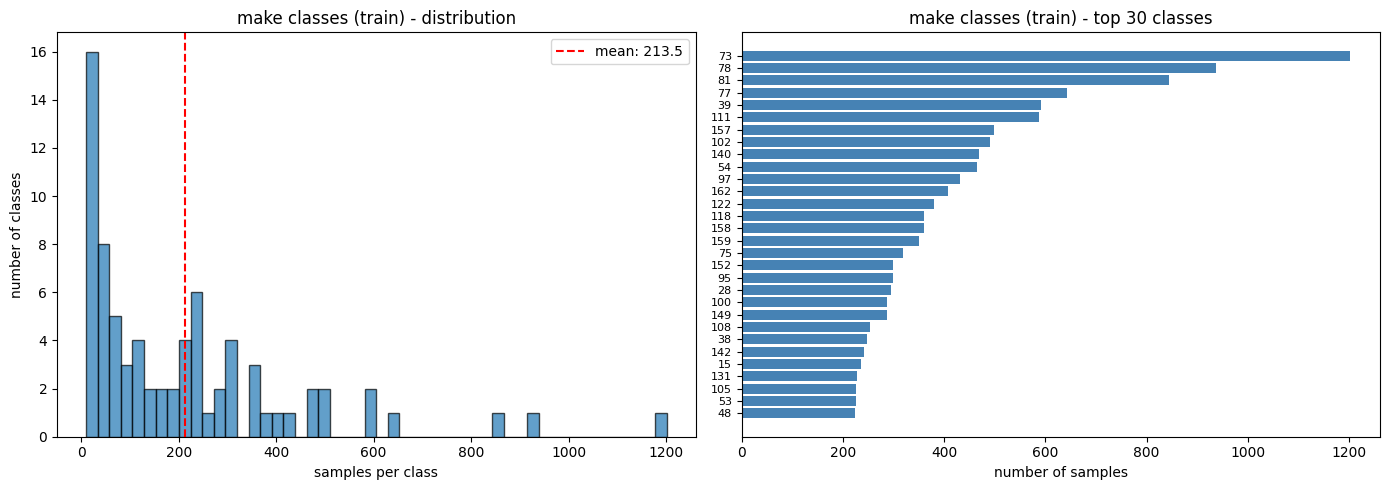

saved: results\make_distribution.png


In [10]:
# plot make class distribution
plot_class_distribution(
    train_stats['make_counts'],
    "make classes (train)",
    str(RESULTS_DIR / "make_distributio n.png")
)

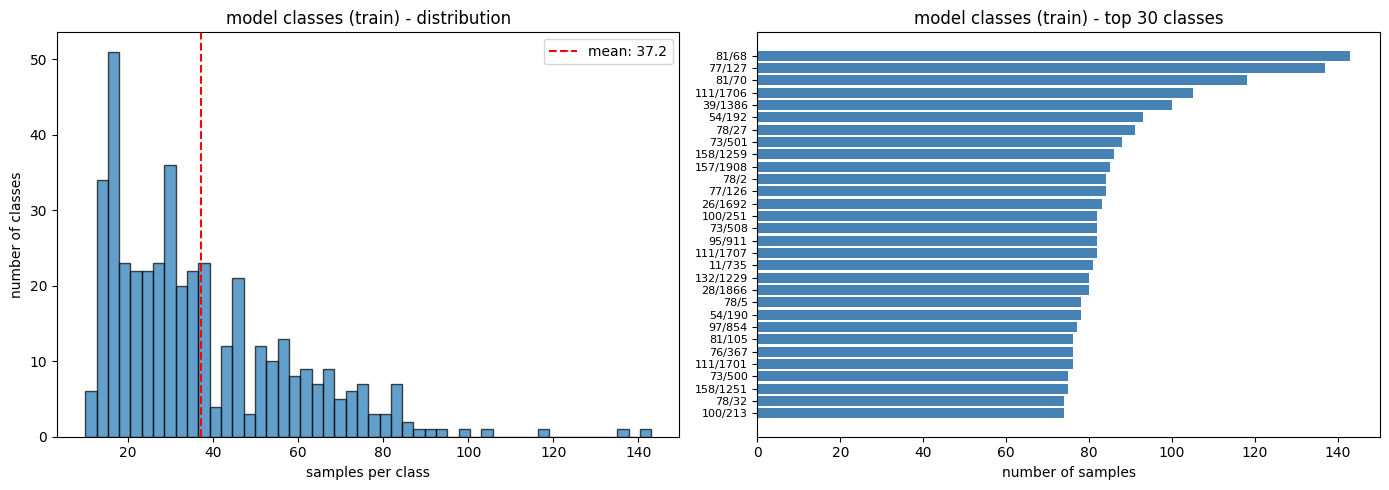

saved: results\model_distribution.png


In [11]:
# plot model class distribution
plot_class_distribution(
    train_stats['model_counts'],
    "model classes (train)",
    str(RESULTS_DIR / "model_distribution.png"),
    top_n=30
)

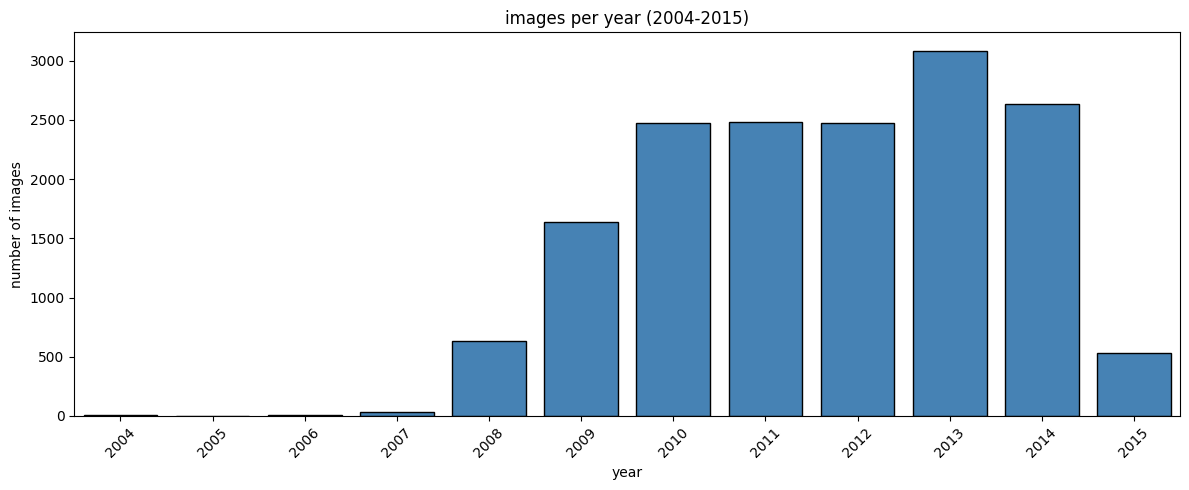

saved: results\year_distribution.png


In [12]:
# plot year distribution
plot_year_distribution(
    train_stats['year_counts'],
    str(RESULTS_DIR / "year_distribution.png")
)

## 9. Save Statistics Report

In [13]:
# save statistics report
save_statistics_report(
    train_stats,
    test_stats,
    str(RESULTS_DIR / "dataset_statistics.md")
)

saved: results\dataset_statistics.md


## 10. Test Dataset Loading

In [14]:
# test dataset loading
test_dataset_loading(str(DATA_DIR), str(TRAIN_SPLIT))

testing dataset loading...
  dataset size: 16016
  num makes: 75
  num models: 431
  sample image shape: torch.Size([3, 224, 224])
  sample label: 32
  dataset loading test passed!


True

In [15]:
print("\ndata exploration complete!")
print(f"results saved to: {RESULTS_DIR}")


data exploration complete!
results saved to: results
